In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/telco_churn.csv')

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nChurn distribution:\n", df['Churn'].value_counts(normalize=True))

Shape: (7043, 21)

Column types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract        

In [2]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="Telco Churn EDA Report", explorative=True)
profile.to_file("churn_eda_report.html")
print("Report saved!")

ModuleNotFoundError: No module named 'ydata_profiling'

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\churn-prediction\\app\\static\\churn_by_features.png'

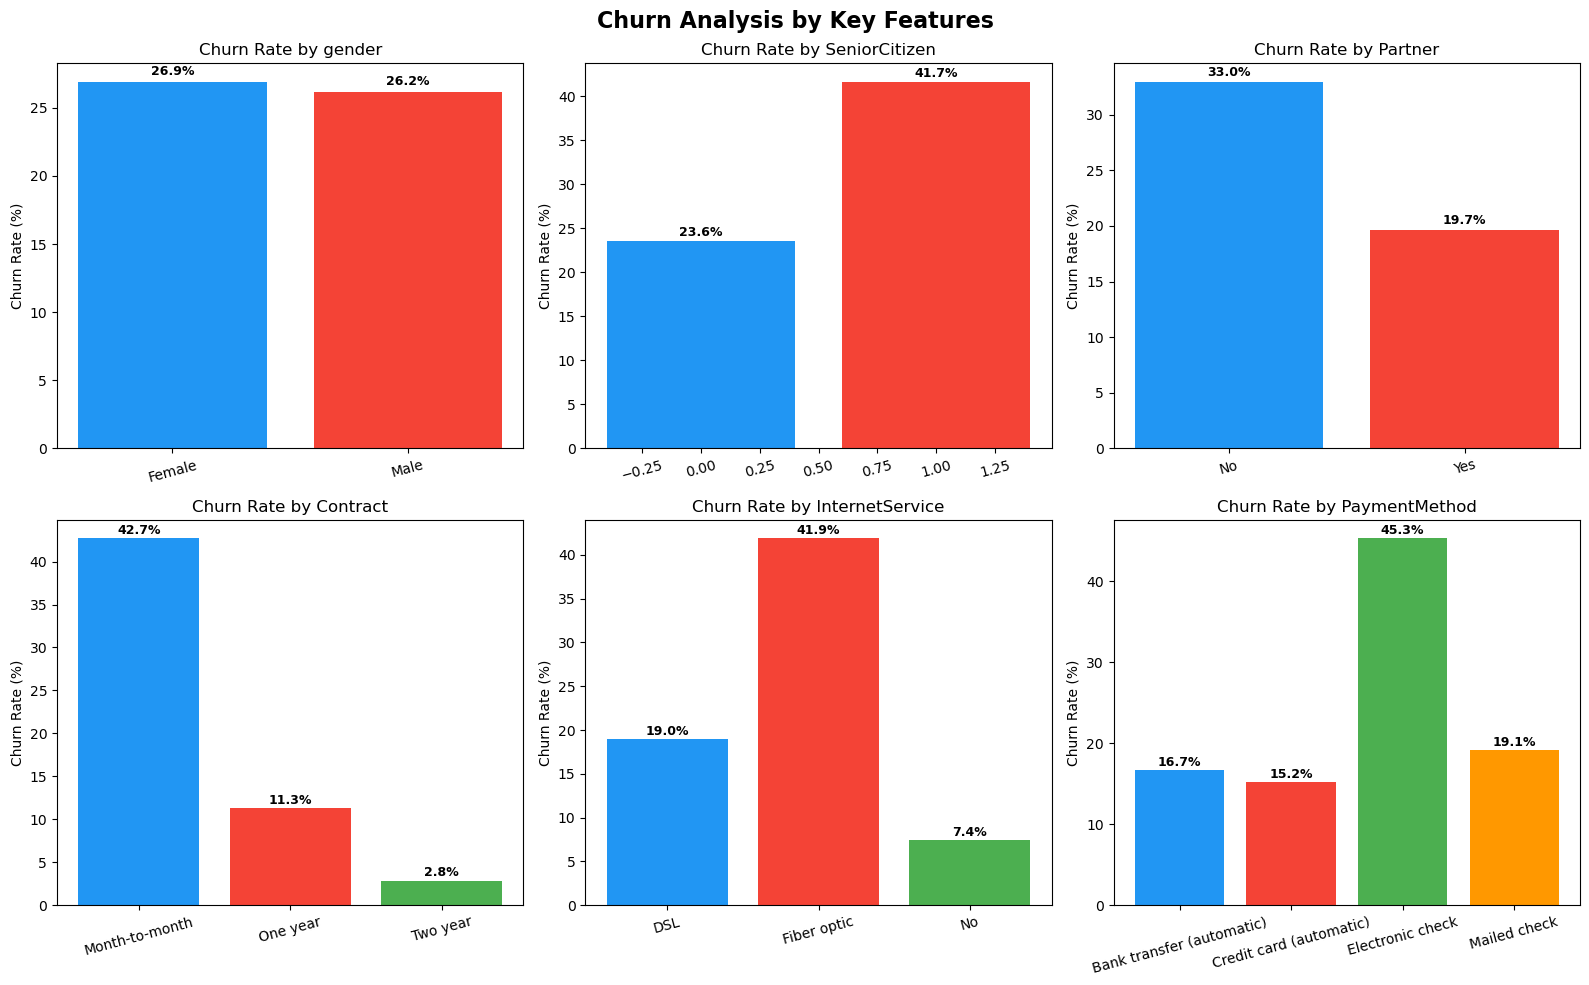

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Churn Analysis by Key Features', fontsize=16, fontweight='bold')

features = ['gender', 'SeniorCitizen', 'Partner', 'Contract', 'InternetService', 'PaymentMethod']

for ax, feature in zip(axes.flatten(), features):
    churn_rate = df.groupby(feature)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [feature, 'ChurnRate']
    bars = ax.bar(churn_rate[feature], churn_rate['ChurnRate'], color=['#2196F3','#F44336','#4CAF50','#FF9800'][:len(churn_rate)])
    ax.set_title(f'Churn Rate by {feature}')
    ax.set_ylabel('Churn Rate (%)')
    for bar, val in zip(bars, churn_rate['ChurnRate']):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../app/static/churn_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df_encoded = df.copy()
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)
df_encoded['TotalCharges'] = pd.to_numeric(df_encoded['TotalCharges'], errors='coerce')

numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df_encoded[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../app/static/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()